 ## ***9. Which risk factors are more prevalent among patients who died?***

Reasoning: Compare proportions of anaemia, diabetes, smoking, and hypertension among deceased vs surviving patients. Useful visuals: Grouped bar charts.
Why it matters: Helps identify which comorbidities are more common in the high-risk group.




               risk_factor  died_count  survived_count
0                 diabetes          13             453
1                     copd           4             229
2           mod_severe_ckd          24             450
3  cerebrovascular_disease           6             144
4                 dementia           1             114


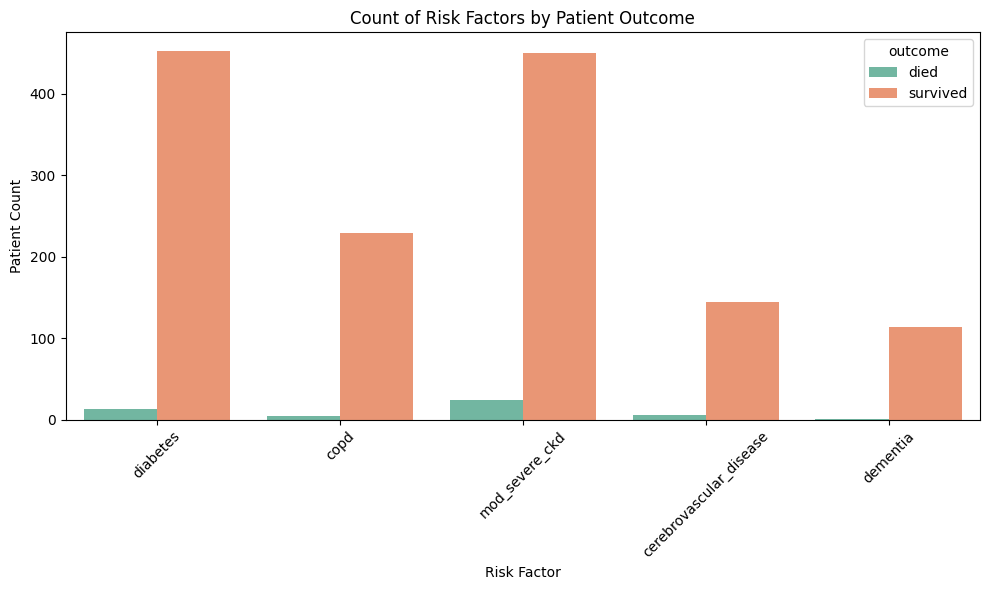

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Load datasets
hf_df = pd.read_csv("cleaned_files/heart_failure_merged.csv")

# 2) Merge on patient_id
df = hf_df.copy()

# 3) Define death outcome
df["died"] = (
    (df["in_hosp_outcome"].astype(str).str.lower() == "dead") |
    (df["mortality_28d"] == 1) |
    (df["death_3mo"] == 1) |
    (df["mortality_3mo"] == 1)
).astype(int)

# 4) Risk factors available in dataset
risk_factors = [
    "diabetes",
    "copd",
    "mod_severe_ckd",
    "cerebrovascular_disease",
    "dementia"
]

# Convert to binary counts: 0 = no, 1 = yes
for col in risk_factors:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)
    df[col] = (df[col] > 0).astype(int)

# 5) Compare counts by outcome
comparison = []
for col in risk_factors:
    died_count = int(df.loc[df["died"] == 1, col].sum())
    survived_count = int(df.loc[df["died"] == 0, col].sum())

    comparison.append({
        "risk_factor": col,
        "died_count": died_count,
        "survived_count": survived_count
    })

comparison_df = pd.DataFrame(comparison)
print(comparison_df)

# 6) Prepare data for grouped bar chart
plot_df = comparison_df.melt(
    id_vars="risk_factor",
    value_vars=["died_count", "survived_count"],
    var_name="outcome",
    value_name="count"
)

plot_df["outcome"] = plot_df["outcome"].str.replace("_count", "", regex=False)

# 7) Plot grouped bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x="risk_factor", y="count", hue="outcome", palette="Set2")
plt.title("Count of Risk Factors by Patient Outcome")
plt.ylabel("Patient Count")
plt.xlabel("Risk Factor")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### ***Q10.How long are patients hospitalized?***

Reasoning: Here we are analyzing using Length of Stay (LOS) in days.

Overall LOS summary
   n_patients  mean_days  median_days  std_days  min_days  p25_days  p75_days  \
0        2008       9.42          8.0      8.03         1       6.0      10.0   

   p90_days  p95_days  max_days  
0      15.0      21.0       123  

LOS by outcome
      n  mean  median   std  p25   p75   p90   p95  min  max   outcome
0  1951  9.47     8.0  7.97  6.0  10.0  15.0  20.5    1  123  survived
1    57  7.65     5.0  9.83  2.0   9.0  17.4  25.2    1   62      died


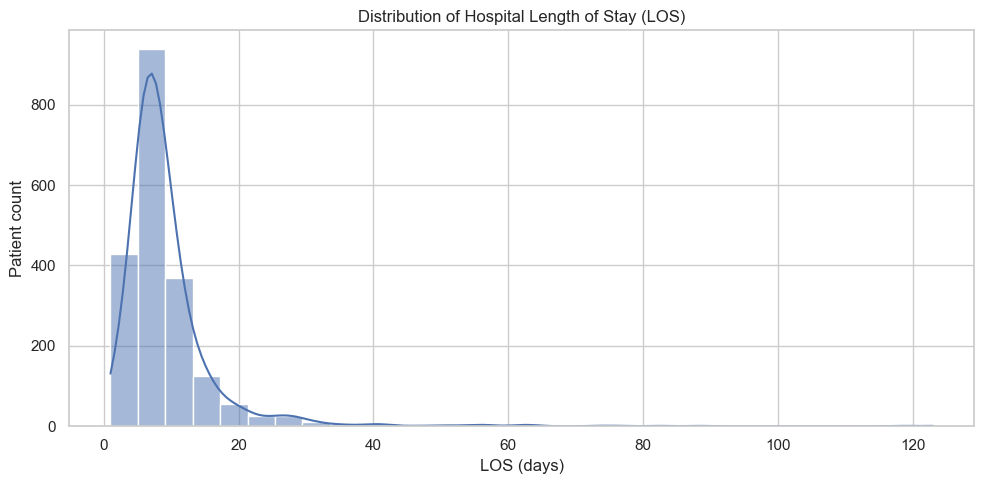

/var/folders/dk/53qw_7r15q18hjcxfln983jh0000gn/T/ipykernel_82533/4014337988.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="died", y="los_days", palette="Set2")


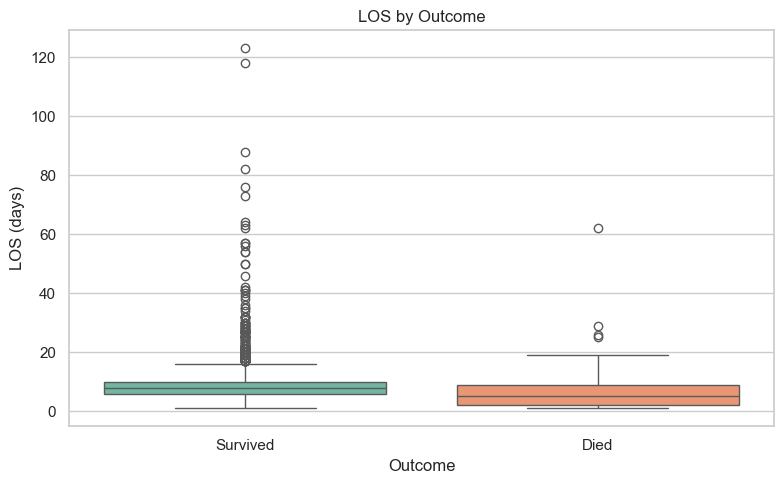

In [9]:


# 3) Build LOS column (days) robustly
# First try direct LOS columns; else compute from admission/discharge dates
candidate_los_cols = [
    "los_days", "length_of_stay", "hospital_los", "hosp_los_days", "stay_days"
]

los_col = next((c for c in candidate_los_cols if c in df.columns), None)

if los_col is not None:
    df["los_days"] = pd.to_numeric(df[los_col], errors="coerce")
else:
    # Try date difference if date columns exist
    admit_candidates = ["admit_date", "admission_date", "hospital_admit_date", "admittime"]
    discharge_candidates = ["discharge_date", "hospital_discharge_date", "dischtime"]

    admit_col = next((c for c in admit_candidates if c in df.columns), None)
    discharge_col = next((c for c in discharge_candidates if c in df.columns), None)

    if admit_col and discharge_col:
        df[admit_col] = pd.to_datetime(df[admit_col], errors="coerce")
        df[discharge_col] = pd.to_datetime(df[discharge_col], errors="coerce")
        df["los_days"] = (df[discharge_col] - df[admit_col]).dt.total_seconds() / (24 * 3600)
    else:
        # Fallback: use an existing LOS-like column if available
        fallback_los_candidates = [
            "discharge_day", "stay_length", "length_of_stay", "los", "hospital_los"
        ]
        fallback_los_col = next((c for c in fallback_los_candidates if c in df.columns), None)

        if fallback_los_col is not None:
            df["los_days"] = pd.to_numeric(df[fallback_los_col], errors="coerce")
        else:
            raise ValueError(
            "No LOS column or admission/discharge date columns found. "
            "Please check for a stay-length column such as 'discharge_day'."
            )

# Keep valid LOS values only
df = df[df["los_days"].notna()].copy()
df = df[df["los_days"] >= 0].copy()

# 4) Overall LOS summary
summary = {
    "n_patients": len(df),
    "mean_days": df["los_days"].mean(),
    "median_days": df["los_days"].median(),
    "std_days": df["los_days"].std(),
    "min_days": df["los_days"].min(),
    "p25_days": df["los_days"].quantile(0.25),
    "p75_days": df["los_days"].quantile(0.75),
    "p90_days": df["los_days"].quantile(0.90),
    "p95_days": df["los_days"].quantile(0.95),
    "max_days": df["los_days"].max(),
}
summary_df = pd.DataFrame([summary]).round(2)
print("Overall LOS summary")
print(summary_df)

# 5) LOS by outcome
by_outcome = (
    df.groupby("died")["los_days"]
    .agg(
        n="count",
        mean="mean",
        median="median",
        std="std",
        p25=lambda s: s.quantile(0.25),
        p75=lambda s: s.quantile(0.75),
        p90=lambda s: s.quantile(0.90),
        p95=lambda s: s.quantile(0.95),
        min="min",
        max="max"
    )
    .reset_index()
)
by_outcome["outcome"] = by_outcome["died"].map({0: "survived", 1: "died"})
by_outcome = by_outcome.drop(columns="died").round(2)
print("\nLOS by outcome")
print(by_outcome)

# 6) Visuals
sns.set(style="whitegrid")

# Histogram
plt.figure(figsize=(10, 5))
sns.histplot(df["los_days"], bins=30, kde=True, color="#4C72B0")
plt.title("Distribution of Hospital Length of Stay (LOS)")
plt.xlabel("LOS (days)")
plt.ylabel("Patient count")
plt.tight_layout()
plt.show()

# Boxplot by outcome
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="died", y="los_days", palette="Set2")
plt.xticks([0, 1], ["Survived", "Died"])
plt.title("LOS by Outcome")
plt.xlabel("Outcome")
plt.ylabel("LOS (days)")
plt.tight_layout()
plt.show()